# 📝 Ejercicio Guiado — Regresión Lineal: Predicción de Ganancias en Startups

**Nombre:** Hellen Yanes Doria  
**Fecha:** 24-febrero-2026

---

En este ejercicio construirás un modelo de **Regresión Lineal** para predecir las ganancias (`Profit`) de startups en distintos estados de EE.UU., a partir de sus gastos en I+D, administración y marketing.

Seguirás los mismos pasos del notebook que revisamos en clase, pero con algunas variaciones importantes en el preprocesamiento:

| Paso | Notebook que vimos | **Este ejercicio** |
|---|---|---|
| Escalado numérico | `StandardScaler` | **`MinMaxScaler`** |
| Variable categórica | `OneHotEncoder` | **`OrdinalEncoder`** |
| Predicción final | — | **Muestra sintética propia** |

El dataset proviene de Kaggle:  
📦 [Startup - Multiple Linear Regression](https://www.kaggle.com/datasets/karthickveerakumar/startup-logistic-regression)

Contiene información de **50 startups** con las siguientes columnas:

| Columna | Tipo | Descripción |
|---|---|---|
| `R&D Spend` | Numérica | Gasto en Investigación y Desarrollo (USD) |
| `Administration` | Numérica | Gasto en Administración (USD) |
| `Marketing Spend` | Numérica | Gasto en Marketing (USD) |
| `State` | Categórica | Estado de EE.UU. (New York, California, Florida) |
| `Profit` | Numérica 🎯 | **Variable objetivo** — Ganancia de la startup (USD) |

> 💡 **Recuerda:** como `Profit` es una variable continua (un número real), este es un problema de **regresión**, no de clasificación.

## 0. Descarga del dataset

Descarga el archivo `50_Startups.csv` desde Kaggle y súbelo a la misma carpeta del notebook.

**Opción A – Kaggle API:**
```bash
!pip install kaggle -q
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d karthickveerakumar/startup-logistic-regression --unzip
```

**Opción B – Descarga manual:**  
Descarga `50_Startups.csv` desde la página de Kaggle y súbelo a este entorno.

**Opción C – Datos sintéticos** *(si no tienes acceso a Kaggle)*:  
Por si no tienes acceso a Kaggle, el profesor subirá el dataset a la carpeta Lecture_06/notebooks/data 

In [1]:
!pip install kaggle -q
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d karthickveerakumar/startup-logistic-regression --unzip


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
The syntax of the command is incorrect.


Dataset URL: https://www.kaggle.com/datasets/karthickveerakumar/startup-logistic-regression
License(s): unknown




  0%|          | 0.00/1.30k [00:00<?, ?B/s]
100%|██████████| 1.30k/1.30k [00:00<00:00, 1.51MB/s]


## 1. Importación de librerías

Importa todas las librerías que necesitarás a lo largo del ejercicio.

**Pistas:**
- Necesitarás `numpy` y `pandas` para manipular datos
- De `sklearn.model_selection` importa la función para dividir train/test
- De `sklearn.pipeline` importa `Pipeline`
- De `sklearn.compose` importa `ColumnTransformer`
- De `sklearn.preprocessing` importa **`MinMaxScaler`** y **`OrdinalEncoder`** *(ojo: no StandardScaler ni OneHotEncoder esta vez)*
- De `sklearn.impute` importa `SimpleImputer`
- De `sklearn.linear_model` importa `LinearRegression`
- De `sklearn.metrics` importa `mean_absolute_error`, `mean_squared_error` y `r2_score`
- Importa `matplotlib.pyplot` para graficar

> 💡 **¿Qué es MinMaxScaler?**  
> Transforma cada variable numérica al rango **[0, 1]** aplicando la siguiente fórmula a cada valor:  
> `x_scaled = (x - x_min) / (x_max - x_min)`  
> A diferencia de `StandardScaler` que centra los datos en 0 con desviación estándar 1, `MinMaxScaler` **preserva la forma de la distribución** y garantiza un rango acotado. Es útil cuando el algoritmo es sensible a la magnitud de los valores.

In [1]:
# Importa aquí todas las librerías necesarias:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Carga de datos

Carga el archivo `50_Startups.csv` y haz una exploración inicial completa.

**Pistas:**
- Usa `pd.read_csv(...)` para cargar el archivo
- Usa `.shape` para ver las dimensiones
- Usa `.head()` para ver las primeras filas
- Usa `.info()` o `.dtypes` para ver los tipos de cada columna
- Usa `.describe()` para estadísticos básicos de columnas numéricas
- Usa `.isnull().sum()` para detectar valores nulos
- Usa `.value_counts()` sobre la columna `State` para ver cuántas startups hay por estado

In [4]:
# Carga el dataset:
df = pd.read_csv('50_Startups.csv')
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [6]:
# Visualiza las primeras filas del dataset
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [7]:
# Revisa tipos de datos y valores nulos:
# Tipos de datos
df.info()

# Valores nulos por columna
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [8]:
# Estadísticos descriptivos de las columnas numéricas:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [9]:
# Cuantas startups hay por Estado:
df['State'].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

## 3. Separación de X e y — División en train, val y test

Separa las features (X) de la variable objetivo (y), y divide el dataset en **tres conjuntos** distintos.

**¿Por qué tres conjuntos?**

| Conjunto | Tamaño | Rol |
|---|---|---|
| **Train** | ~64 % | Ajusta los parámetros del modelo (coeficientes e intercepto) |
| **Val** | ~16 % | Evalúa el modelo *durante el desarrollo*: detecta sobreajuste, compara variantes, guía decisiones |
| **Test** | ~20 % | Evaluación **final y única** — nunca se usa para tomar decisiones de desarrollo |

**Estrategia — dos divisiones sucesivas:**

1. Separa primero el **20 %** como test set (queda «bloqueado» hasta el final).
2. Del 80 % restante (`X_trainval`, `y_trainval`), separa otro **20 %** como val set.

Esto resulta en aprox. **64 % train / 16 % val / 20 % test**.

**Pistas:**
- Llama a `train_test_split` **dos veces**, ambas con `random_state=42`
- Primera llamada: `test_size=0.2` → produce `X_trainval` y `X_test`
- Segunda llamada: `test_size=0.2` → produce `X_train` y `X_val`
- Variables finales: `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`
- Imprime el `.shape` de los seis arreglos para verificar los tamaños

> ⚠️ **Regla de oro:** el test set **nunca** debe usarse para ajustar parámetros, escalar datos ni elegir entre dos modelos. Para esas decisiones existe el val set. Si usas test para tomar decisiones de desarrollo, estás cometiendo *data leakage* sin darte cuenta y las métricas finales serán optimistas.

In [10]:
# Define X e y
X = df.drop('Profit', axis=1)
y = df['Profit']

# ── División en dos pasos ──────────────────────────────────────────────────────
# Paso 1: reserva el 20 % como test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Paso 2: del 80 % restante, separa un 20 % como val set
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.2,
    random_state=42
)

# ── Verifica los tamaños ───────────────────────────────────────────────────────
print("Train :", X_train.shape, y_train.shape)
print("Val   :", X_val.shape,   y_val.shape)
print("Test  :", X_test.shape,  y_test.shape)

Train : (32, 4) (32,)
Val   : (8, 4) (8,)
Test  : (10, 4) (10,)


## 4. Preprocesamiento

Construirás un `ColumnTransformer` con dos pipelines diferenciados por tipo de columna.

---

### 4a. Pipeline para variables numéricas

Las columnas numéricas son: `R&D Spend`, `Administration`, `Marketing Spend`.

Aplica estos dos pasos **en orden dentro de un `Pipeline`**:
1. `SimpleImputer(strategy='mean')` — rellena valores nulos con la media
2. `MinMaxScaler()` — escala cada variable al rango [0, 1]

> 💡 El orden importa: primero imputar, luego escalar. Si lo haces al revés, el scaler no sabrá cómo manejar los NaN.

---

### 4b. Pipeline para la variable categórica

La única columna categórica es `State`, con tres valores posibles: `New York`, `California`, `Florida`.

Aplica estos dos pasos:
1. `SimpleImputer(strategy='most_frequent')` — rellena nulos con la categoría más frecuente
2. `OrdinalEncoder(categories=[['California', 'Florida', 'New York']])` — convierte las categorías a números según el orden que definas

> 💡 **¿Cuándo usar OrdinalEncoder vs OneHotEncoder?**
>
> | Encoder | Cuándo usarlo | Ejemplo |
> |---|---|---|
> | `OneHotEncoder` | Categorías **sin orden** → crea columnas binarias separadas | colores, países, géneros |
> | `OrdinalEncoder` | Categorías **con orden natural** → asigna 0, 1, 2... | bajo/medio/alto, grado escolar |
>
> En este caso `State` **no tiene un orden real**. Usarlo con `OrdinalEncoder` es una decisión simplificadora — en el paso 8 reflexionarás si fue la correcta.
>
> El parámetro `categories` te permite controlar exactamente qué número recibe cada estado:  
> `California → 0`, `Florida → 1`, `New York → 2`

---

### 4c. ColumnTransformer

Combina ambos pipelines en un `ColumnTransformer`.

**Pistas:**
- Primero define listas con los nombres de columnas numéricas y categóricas
- La estructura del `ColumnTransformer` es:
```python
ColumnTransformer(transformers=[
    ('nombre_a', pipeline_numerico,    lista_cols_numericas),
    ('nombre_b', pipeline_categorico,  lista_cols_categoricas)
])
```

In [11]:
# Identifica las columnas numéricas y categóricas:
numerical_cols = ['R&D Spend', 'Administration', 'Marketing Spend']
categorical_cols = ['State']


In [12]:
# Crea el pipeline para variables numéricas:
# Paso 1: SimpleImputer con strategy='mean'
# Paso 2: MinMaxScaler
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())
])

In [13]:
# Crea el pipeline para la variable categórica:
# Paso 1: SimpleImputer con strategy='most_frequent'
# Paso 2: OrdinalEncoder con el orden: California → Florida → New York
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[['California', 'Florida', 'New York']]))
])

In [14]:
# Crea el ColumnTransformer combinando ambos pipelines:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

## 5. Definición del modelo en Pipeline

Encadena el `ColumnTransformer` y el modelo `LinearRegression()` en un único `Pipeline`.

**Pistas:**
```python
pipe = Pipeline(steps=[
    ('preprocess', tu_column_transformer),
    ('model', LinearRegression())
])
```
- Imprime el pipeline para verificar su estructura

> 💡 **¿Por qué usar Pipeline en lugar de transformar los datos manualmente?**  
> Si transformas `X` completo antes de dividir en los tres conjuntos, el scaler «ve» los valores de val y test durante el ajuste — eso se llama **data leakage** y hace que las métricas sean artificialmente optimistas. El Pipeline garantiza que `.fit()` solo se aplica a `X_train`, y `.transform()` se aplica por separado a `X_val` y `X_test`, asegurando una evaluación honesta en los tres conjuntos.

In [15]:
# Define el Pipeline completo (preprocesamiento + modelo):
# Pipeline completo: preprocesamiento + modelo
pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

pipe

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 6. Entrenamiento

Entrena el pipeline con los datos de entrenamiento.

**Pistas:**
- Un solo `pipe.fit(X_train, y_train)` hace todo: aprende el escalado, el encoding y los coeficientes de la regresión
- Luego extrae los coeficientes para interpretar el modelo:
  - Accede al modelo con `pipe.named_steps['model']`
  - Los coeficientes están en `.coef_` y el intercepto en `.intercept_`
- Construye un DataFrame con el nombre de cada feature y su coeficiente
- Los nombres de features son: las columnas numéricas primero, luego la categórica

> 💡 **Interpretación de coeficientes con MinMaxScaler:**  
> Como todas las variables numéricas están en [0, 1], un coeficiente mayor indica más influencia sobre `Profit`. Sin embargo, el coeficiente de `State` (que tomará valores 0, 1 ó 2) **no está en la misma escala** — tenlo en cuenta al comparar.

In [17]:
# Entrena el pipeline con los datos de entrenamiento:
pipe.fit(X_train, y_train)

# Extrae e imprime los coeficientes del modelo junto a los nombres de las features:
# Accede al modelo entrenado
model = pipe.named_steps['model']

# Extrae coeficientes e intercepto
coeficientes = model.coef_
intercepto = model.intercept_

print("Intercepto:", intercepto)

# Nombres de las features
feature_names = numerical_cols + categorical_cols

# DataFrame con coeficientes
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coeficiente': coeficientes
})

coef_df

Intercepto: 48340.051174756314


,Feature,Coeficiente
0,R&D Spend,133517.505633
1,Administration,-7428.318467
2,Marketing Spend,15336.269257
3,State,-703.818381


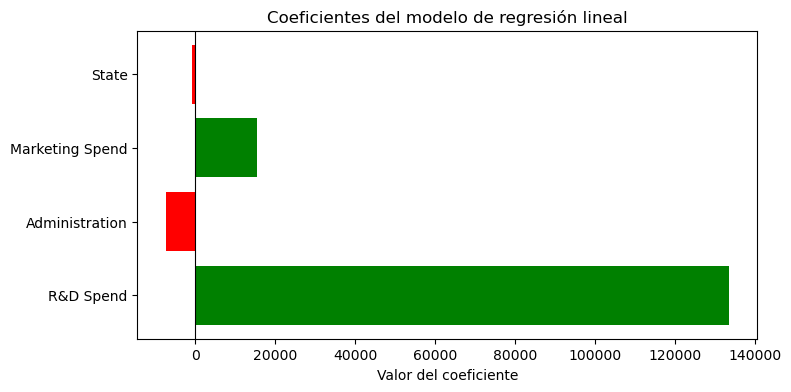

In [18]:
# Grafica los coeficientes como barras horizontales.
# Pistas:
#   - Usa plt.barh(nombres, valores)
#   - Colorea en verde los coeficientes positivos y en rojo los negativos
#     Truco: colors = ['green' if v > 0 else 'red' for v in valores]
#   - Agrega una línea vertical en x=0 con plt.axvline(0, color='black', linewidth=0.8)
#   - Agrega título y etiqueta al eje x

# Valores y nombres
valores = coef_df['Coeficiente']
nombres = coef_df['Feature']

# Colores según signo
colors = ['green' if v > 0 else 'red' for v in valores]

# Gráfica
plt.figure(figsize=(8, 4))
plt.barh(nombres, valores, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes del modelo de regresión lineal')
plt.xlabel('Valor del coeficiente')
plt.show()


## 7. Evaluación en los tres conjuntos

Evalúa el modelo con las tres métricas estándar de regresión sobre **train, val y test**.

**Pistas:**
- Genera predicciones con `pipe.predict(...)` para cada conjunto
- Calcula las siguientes métricas para los **tres conjuntos**:
  - **MAE** — error promedio absoluto en USD
  - **RMSE** — `sqrt(mean_squared_error(...))` — penaliza más los errores grandes
  - **R²** — fracción de varianza explicada (entre 0 y 1)
- Construye una tabla resumen con las tres filas (Train / Val / Test) y las tres columnas de métricas

**¿Cómo interpretar la comparación?**

| Escenario | Train | Val | Test | Diagnóstico |
|---|---|---|---|---|
| Buen ajuste | R² alto | R² similar | R² similar | Modelo generaliza bien |
| Sobreajuste | R² alto | R² mucho menor | — | El modelo memorizó el train |
| Subajuste | R² bajo | R² bajo | — | El modelo es demasiado simple |

> ⚠️ **Orden correcto de uso:**  
> 1. Usa **val** para detectar sobreajuste y comparar variantes del modelo.  
> 2. Solo cuando estés satisfecho con el modelo mira el **test** una única vez.  
> Si ajustas el modelo basándote en el test, ese resultado ya no es una estimación honesta del rendimiento real.

Luego genera estas visualizaciones:
1. **Real vs Predicho:** compara val y test en subplots lado a lado
2. **Residuos:** histogramas de `y_val - y_pred_val` y `y_test - y_pred_test` con línea vertical en 0

> 💡 Si los residuos se distribuyen simétricamente alrededor de 0 el modelo no tiene sesgo sistemático. Si val y test muestran patrones similares, el modelo generaliza de forma consistente.

In [ ]:
import math

# ── Predicciones en los tres conjuntos ────────────────────────────────────────
y_pred_train = pipe.predict(X_train)
y_pred_val   = pipe.predict(X_val)
y_pred_test  = pipe.predict(X_test)

# ── Métricas ──────────────────────────────────────────────────────────────────
# Completa las líneas de abajo con las llamadas correctas a las funciones importadas.
# Recuerda: RMSE = sqrt(mean_squared_error(...))

results = {
    'Conjunto': ['Train', 'Val', 'Test'],
    'MAE': [
        mean_absolute_error(y_train, y_pred_train),
        mean_absolute_error(y_val, y_pred_val),
        mean_absolute_error(y_test, y_pred_test)
    ],
    'RMSE': [
        math.sqrt(mean_squared_error(y_train, y_pred_train)),
        math.sqrt(mean_squared_error(y_val, y_pred_val)),
        math.sqrt(mean_squared_error(y_test, y_pred_test))
    ],
    'R²': [
        r2_score(y_train, y_pred_train),
        r2_score(y_val, y_pred_val),
        r2_score(y_test, y_pred_test)
    ],
}

df_metrics = pd.DataFrame(results).set_index('Conjunto')
df_metrics = df_metrics.round(2)
print(df_metrics)

# ── Diagnóstico rápido ────────────────────────────────────────────────────────
# Los valores de R² en Train y Val son similares, lo que indica que el modelo
# no presenta sobreajuste significativo y generaliza de forma adecuada.
# El rendimiento en Test es consistente con Val, por lo que el modelo mantiene
# su capacidad predictiva en datos no vistos.

              MAE     RMSE    R²
Conjunto                        
Train     6504.72  9029.75  0.95
Val       7675.95  8981.60  0.96
Test      6840.66  9048.47  0.90


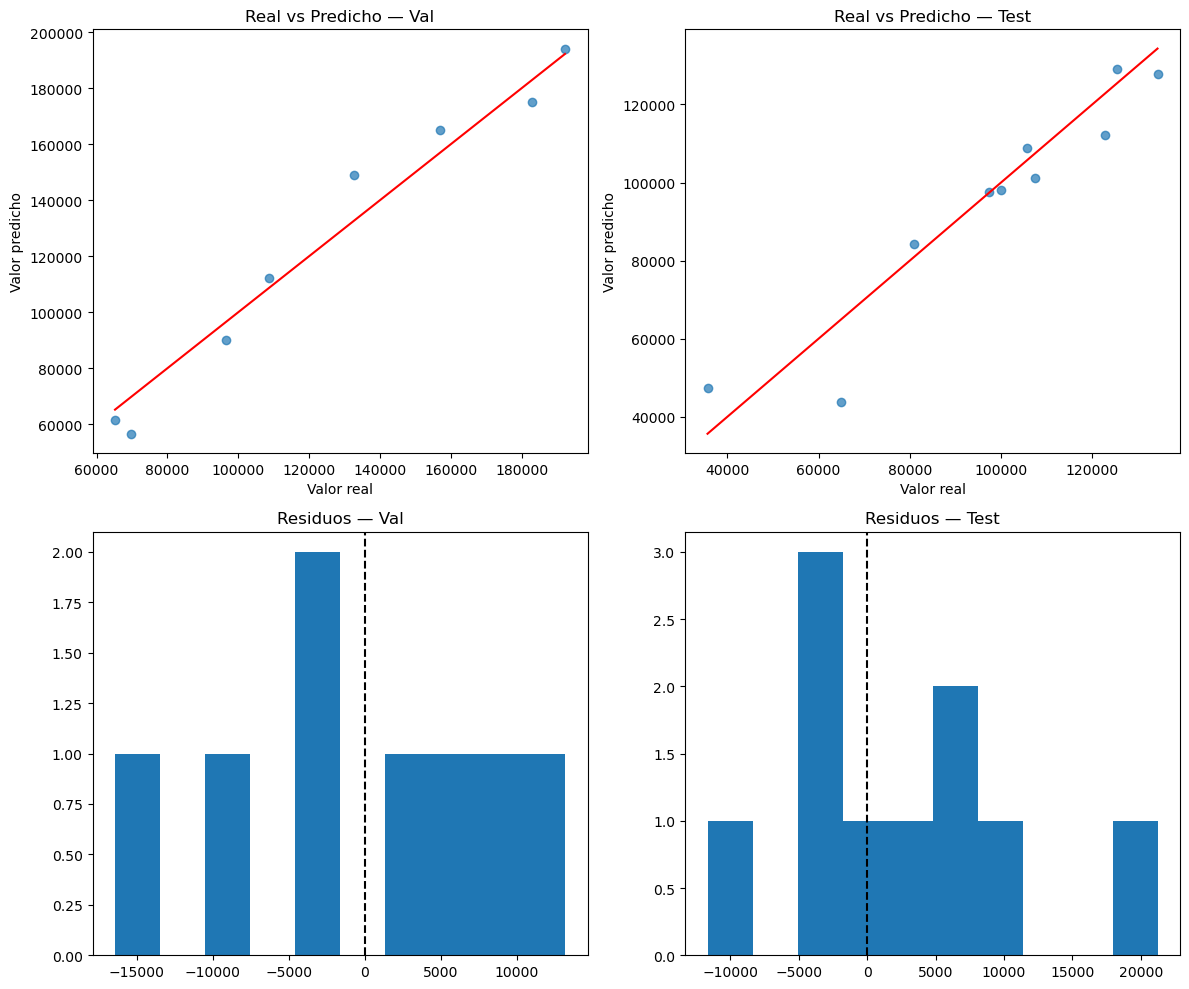

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ── Gráfica 1a — Real vs Predicho (Val) ──────────────────────────────────────
# Usa axes[0, 0]
# plt.sca(axes[0, 0])
# Dispersión: y_val vs y_pred_val (alpha=0.7)
# Línea diagonal roja de predicción perfecta
# Etiqueta los ejes y agrega título "Real vs Predicho — Val"
plt.sca(axes[0, 0])
plt.scatter(y_val, y_pred_val, alpha=0.7)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         color='red')
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title('Real vs Predicho — Val')


# ── Gráfica 1b — Real vs Predicho (Test) ─────────────────────────────────────
# Usa axes[0, 1]
# Misma estructura que 1a pero con y_test e y_pred_test
# Título: "Real vs Predicho — Test"
# ¿Se ven patrones distintos entre val y test?
# En el conjunto de validación, la mayoría de los puntos se alinean
# razonablemente cerca de la línea diagonal, lo que indica buenas predicciones.
# En el conjunto de test se observa un patrón similar, aunque con una ligera
# mayor dispersión en algunos puntos, especialmente en valores bajos de Profit.
# No se observan patrones sistemáticos distintos entre val y test.

plt.sca(axes[0, 1])
plt.scatter(y_test, y_pred_test, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title('Real vs Predicho — Test')


# ── Gráfica 2a — Residuos (Val) ───────────────────────────────────────────────
# Usa axes[1, 0]
# residuals_val = y_val - y_pred_val
# Histograma con bins=10
# Línea vertical en 0: plt.axvline(0, color='black', linestyle='--')
# Título: "Residuos — Val"
plt.sca(axes[1, 0])
residuals_val = y_val - y_pred_val
plt.hist(residuals_val, bins=10)
plt.axvline(0, color='black', linestyle='--')
plt.title('Residuos — Val')

# ── Gráfica 2b — Residuos (Test) ──────────────────────────────────────────────
# Usa axes[1, 1]
# residuals_test = y_test - y_pred_test
# Misma estructura que 2a pero con residuals_test
# Título: "Residuos — Test"
plt.sca(axes[1, 1])
residuals_test = y_test - y_pred_test
plt.hist(residuals_test, bins=10)
plt.axvline(0, color='black', linestyle='--')
plt.title('Residuos — Test')

# Observación de residuos:
# Los residuos en validación se distribuyen alrededor de 0 sin un sesgo claro,
# aunque se observan algunos errores moderados.
# En test, los residuos también se centran cerca de 0, con una distribución
# ligeramente más dispersa pero sin asimetrías marcadas.
# Esto indica que el modelo no presenta un sesgo sistemático importante.

plt.tight_layout()
plt.show()

# ── Reflexión visual ──────────────────────────────────────────────────────────
# Las gráficas de validación y test son consistentes entre sí.
# Los residuos en ambos conjuntos se concentran alrededor de 0,
# lo que sugiere que el modelo generaliza bien y mantiene estabilidad
# en datos no vistos.

## 8. Reflexión sobre el preprocesamiento y la división de datos

Responde estas preguntas **en esta celda** (doble clic para editar):

---

**Pregunta 1:**  
¿Qué diferencia conceptual hay entre `MinMaxScaler` y `StandardScaler`? ¿En qué situación preferirías usar cada uno?

MinMaxScaler transforma los datos para que queden en un rango fijo, normalmente entre 0 y 1. Esto ayuda a que todas las variables estén en la misma escala.
StandardScaler transforma los datos para que tengan media 0 y desviación estándar 1.
Usaría MinMaxScaler cuando quiero que los valores queden entre límites claros y no haya números muy grandes.
Usaría StandardScaler cuando los datos tienen valores muy distintos entre sí y quiero que estén más centrados alrededor de 0.

---

**Pregunta 2:**  
`State` no tiene un orden real entre sus valores. ¿Crees que fue una buena decisión usar `OrdinalEncoder`? ¿Qué implicación tiene que el modelo interprete `New York = 2 > Florida = 1 > California = 0`?

No es del todo buena decisión, porque los estados no tienen un orden real.
Al usar OrdinalEncoder, el modelo piensa que un estado es “mayor” que otro solo por el número que se le asignó, aunque en la realidad no sea así.
Esto puede hacer que el modelo interprete mal la información del estado y afecte un poco los resultados. Lo ideal sería usar otro método que no ponga un orden entre los estados.

---

**Pregunta 3:**  
Mirando la gráfica de coeficientes, ¿qué variable tiene más peso en la predicción del `Profit`? ¿Tiene sentido desde el punto de vista de negocio?

La variable que más peso tiene es R&D Spend, porque su coeficiente es el más grande.
Esto tiene sentido, ya que invertir más en investigación y desarrollo normalmente ayuda a que la empresa gane más dinero.

---

**Pregunta 4:**  
¿Para qué sirve específicamente el **val set** en este ejercicio? ¿Qué decisión podrías tomar mirando solo train y val, sin tocar el test?

El conjunto de validación sirve para ver qué tan bien funciona el modelo con datos que no usó para entrenar.
Con train y val se puede decidir si el modelo está funcionando bien o si necesita cambios, sin usar todavía el conjunto de test.

---

**Pregunta 5:**  
Observa los R² de los tres conjuntos en la tabla de métricas. ¿Detectas sobreajuste o subajuste? ¿Qué te dice la diferencia entre R² train y R² val?

No se nota un sobreajuste fuerte porque los valores de R² de train y val son parecidos.
Esto indica que el modelo no solo memoriza los datos de entrenamiento, sino que también funciona de forma similar con datos nuevos.

---

**Pregunta 6:**  
¿Por qué es importante hacer el split **antes** de ajustar el `ColumnTransformer` (y no transformar todo `X` primero y luego dividir)? ¿Qué problema causaría la segunda estrategia?

Es importante dividir los datos antes de transformar porque si se transforman todos juntos, el modelo puede usar información del conjunto de validación y test sin querer.
Esto haría que los resultados parezcan mejores de lo que realmente son.
Al hacer el split primero, el modelo solo aprende con los datos de entrenamiento y la evaluación es más justa.

## 9. 🧪 Prueba con muestra sintética propia

Ahora es tu turno de **inventar** startups ficticias y comprobar si las predicciones del modelo tienen sentido lógico.

La clave es razonar **antes** de ver el resultado: ¿qué Profit esperarías para cada startup?

**Instrucciones:**

1. Diseña **al menos 5 startups** con perfiles muy distintos, por ejemplo:

| Perfil sugerido | R&D Spend | Administration | Marketing Spend | State |
|---|---|---|---|---|
| Alto I+D, poco marketing | alto | medio | bajo | cualquiera |
| Solo marketing, cero I+D | 0 | medio | muy alto | cualquiera |
| Gastos mínimos en todo | bajos | bajos | bajos | cualquiera |
| Startup «promedio» | medio | medio | medio | cualquiera |
| Valores extremos | máximo posible | máximo | máximo | cualquiera |

2. **Antes de ejecutar**, escribe en un comentario cuánto Profit esperas para cada startup.

3. Usa `pipe.predict(muestra)` para obtener las predicciones.

4. Compara tus expectativas con los resultados y reflexiona.

**Pistas:**
- El DataFrame debe tener exactamente las mismas columnas que `X`: `R&D Spend`, `Administration`, `Marketing Spend`, `State`
- Los valores de `State` deben ser exactamente: `'New York'`, `'California'` o `'Florida'`
- Para saber los rangos válidos, revisa el `.describe()` del paso 2
- Estructura base:
```python
muestra = pd.DataFrame({
    'R&D Spend':       [...],
    'Administration':  [...],
    'Marketing Spend': [...],
    'State':           [...]
})
```

In [22]:
# Diseña tus 5+ startups ficticias.
# IMPORTANTE: antes de ejecutar, escribe aquí cuánto Profit esperas para cada una:

# Startup 1 (perfil: ...): espero Profit de aprox. $___
# Startup 2 (perfil: ...): espero Profit de aprox. $___
# Startup 3 (perfil: ...): espero Profit de aprox. $___
# Startup 4 (perfil: ...): espero Profit de aprox. $___
# Startup 5 (perfil: ...): espero Profit de aprox. $___

muestra = pd.DataFrame({
    'R&D Spend':       [180000,   0,    5000,  90000, 200000],
    'Administration':  [120000, 80000, 10000, 70000, 150000],
    'Marketing Spend': [10000, 200000, 5000,  90000, 300000],
    'State':           ['California', 'Florida', 'New York', 'California', 'Florida']
})

muestra

,R&D Spend,Administration,Marketing Spend,State
0,180000,120000,10000,California
1,0,80000,200000,Florida
2,5000,10000,5000,New York
3,90000,70000,90000,California
4,200000,150000,300000,Florida


In [23]:
# Genera las predicciones para tu muestra:
# Pista: predicciones = pipe.predict(muestra)

# Muestra los resultados en una tabla legible.
# Pista: agrega las predicciones como nueva columna al DataFrame de muestra
#   muestra['Profit Predicho'] = predicciones

predicciones = pipe.predict(muestra)

muestra['Profit Predicho'] = predicciones
muestra


,R&D Spend,Administration,Marketing Spend,State,Profit Predicho
0,180000,120000,10000,California,192607.169139
1,0,80000,200000,Florida,52922.152385
2,5000,10000,5000,New York,53545.412479
3,90000,70000,90000,California,124294.782612
4,200000,150000,300000,Florida,216649.174562


### Reflexión final sobre la muestra sintética

Responde aquí (doble clic para editar):

**1. ¿Las predicciones coinciden con lo que esperabas antes de ejecutar?**  
Sí, en general las predicciones coinciden bastante con lo que esperaba. Las startups que tenían mayor inversión en R&D y en general más gastos obtuvieron un Profit más alto, mientras que las que tenían gastos bajos o nada de R&D tuvieron un Profit mucho menor. Esto va de acuerdo con lo que se veía en los coeficientes del modelo.

---

**2. ¿Hubo alguna startup cuya predicción te sorprendió? ¿A qué crees que se debe?**  
La que más me sorprendió fue la startup que tenía mucho gasto en marketing pero nada en R&D, porque el Profit no fue tan alto como pensé al inicio. Creo que esto se debe a que el modelo le da mucho más peso a la inversión en investigación y desarrollo que al marketing.

---

**3. ¿Cambia mucho el Profit predicho según el `State` cuando los gastos son idénticos? ¿Tiene sentido económico ese efecto?**  
No cambia mucho el Profit solo por el State cuando los gastos son iguales. El efecto del State es pequeño comparado con las otras variables. Económicamente tiene sentido, porque el lugar puede influir un poco, pero no debería ser más importante que cuánto se invierte en la empresa.

---

**4. Si el modelo predice un Profit negativo para alguna startup, ¿es eso un error del modelo o algo que podría ocurrir en la realidad?**  
No necesariamente es un error del modelo. En la realidad una startup puede tener pérdidas, sobre todo si tiene pocos ingresos o gastos mal distribuidos. El modelo simplemente está reflejando que, con esos valores de entrada, el negocio no sería rentable.

## 10. 🌟 Desafío opcional

Si terminaste todo lo anterior, prueba al menos uno de estos desafíos adicionales:

---

**Desafío A — OneHotEncoder vs OrdinalEncoder**  
Reemplaza `OrdinalEncoder` por `OneHotEncoder(drop='first')` en el pipeline categórico y vuelve a entrenar.  
¿Cambia el R² en val? ¿Cambia la interpretación de los coeficientes? ¿Cuál crees que es más correcto para `State`?

---

**Desafío B — MinMaxScaler vs StandardScaler**  
Reemplaza `MinMaxScaler` por `StandardScaler` y compara las métricas en val.  
¿Cambia el R²? ¿Cambia la magnitud de los coeficientes? ¿Por qué?

---

**Desafío C — Feature engineering**  
Antes de separar X e y, crea una nueva columna:  
`df['RD_ratio'] = df['R&D Spend'] / (df['R&D Spend'] + df['Marketing Spend'] + 1)`  
Agrega esta columna a `numerical_cols` y comprueba en el **val set** si el R² mejora.  
Solo si mejora en val, consulta el test para la evaluación final.

---

> 💡 **Pista para comparar modelos usando el val set:**  
> Crea una función `evaluar_modelo(pipe, X_train, X_val, y_train, y_val)` que entrene el pipeline y devuelva un diccionario con MAE, RMSE y R² de val. Compara las variantes en una tabla y elige el mejor modelo **mirando solo val**. Cuando hayas decidido, evalúa ese modelo en test una única vez para reportar el rendimiento final.

In [ ]:
# Espacio para el desafío opcional:

